In [11]:
import pandas as pd

In [12]:
df = pd.read_csv("results/reports/final_results.csv")

In [13]:
df.head()

,Model,Accuracy,Precision,Recall,F1,Epochs,prep_windowing,prep_clahe,prep_hist_eq,prep_gaussian,prep_median,prep_sharpen_flag,prep_norm_type,Test_Accuracy
0,resnet50_baseline_ep20,0.885542,0.916589,0.885542,0.894960,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,resnet50_windowing_ep20,0.945783,0.953048,0.945783,0.947803,20,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,resnet50_clahe_ep20,0.963855,0.965397,0.963855,0.964316,20,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
3,resnet50_hist_eq_ep20,0.927711,0.930940,0.927711,0.929030,20,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN
4,resnet50_window_clahe_ep20,0.969880,0.973021,0.969880,0.970671,20,True,True,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Model              72 non-null     object 
 1   Accuracy           72 non-null     float64
 2   Precision          72 non-null     float64
 3   Recall             72 non-null     float64
 4   F1                 72 non-null     float64
 5   Epochs             72 non-null     int64  
 6   prep_windowing     27 non-null     object 
 7   prep_clahe         39 non-null     object 
 8   prep_hist_eq       5 non-null      object 
 9   prep_gaussian      8 non-null      object 
 10  prep_median        16 non-null     object 
 11  prep_sharpen_flag  16 non-null     object 
 12  prep_norm_type     20 non-null     object 
 13  Test_Accuracy      0 non-null      float64
dtypes: float64(5), int64(1), object(8)
memory usage: 8.0+ KB


In [15]:
df.columns = df.columns.str.strip()

In [16]:
cnn_model = [
    "resnet50",
    "vgg16",
    "inception",
    "convextiny",
    "vit"
]

In [17]:
def extract_info(name):
    parts = name.split("_")

    single_model = []
    config_parts = []
    epoch = None

    for p in parts:
        if p in cnn_model:
            single_model.append(p)
        elif p.startswith("ep"):
            continue
        else:
            config_parts.append(p)
        
    parts = [p for p in parts if not p.startswith("ep")]
    single_model = "_".join(single_model)
    config = "_".join(config_parts)

    return pd.Series([single_model,config])

df[["single_model","config"]] = df["Model"].apply(extract_info)

print(df.head())


                        Model  Accuracy  Precision    Recall        F1  \
0      resnet50_baseline_ep20  0.885542   0.916589  0.885542  0.894960   
1     resnet50_windowing_ep20  0.945783   0.953048  0.945783  0.947803   
2         resnet50_clahe_ep20  0.963855   0.965397  0.963855  0.964316   
3       resnet50_hist_eq_ep20  0.927711   0.930940  0.927711  0.929030   
4  resnet50_window_clahe_ep20  0.969880   0.973021  0.969880  0.970671   

   Epochs prep_windowing prep_clahe prep_hist_eq prep_gaussian prep_median  \
0      20            NaN        NaN          NaN           NaN         NaN   
1      20           True        NaN          NaN           NaN         NaN   
2      20            NaN       True          NaN           NaN         NaN   
3      20            NaN        NaN         True           NaN         NaN   
4      20           True       True          NaN           NaN         NaN   

  prep_sharpen_flag prep_norm_type  Test_Accuracy single_model        config  
0      

In [18]:
len(df["single_model"].unique())

5

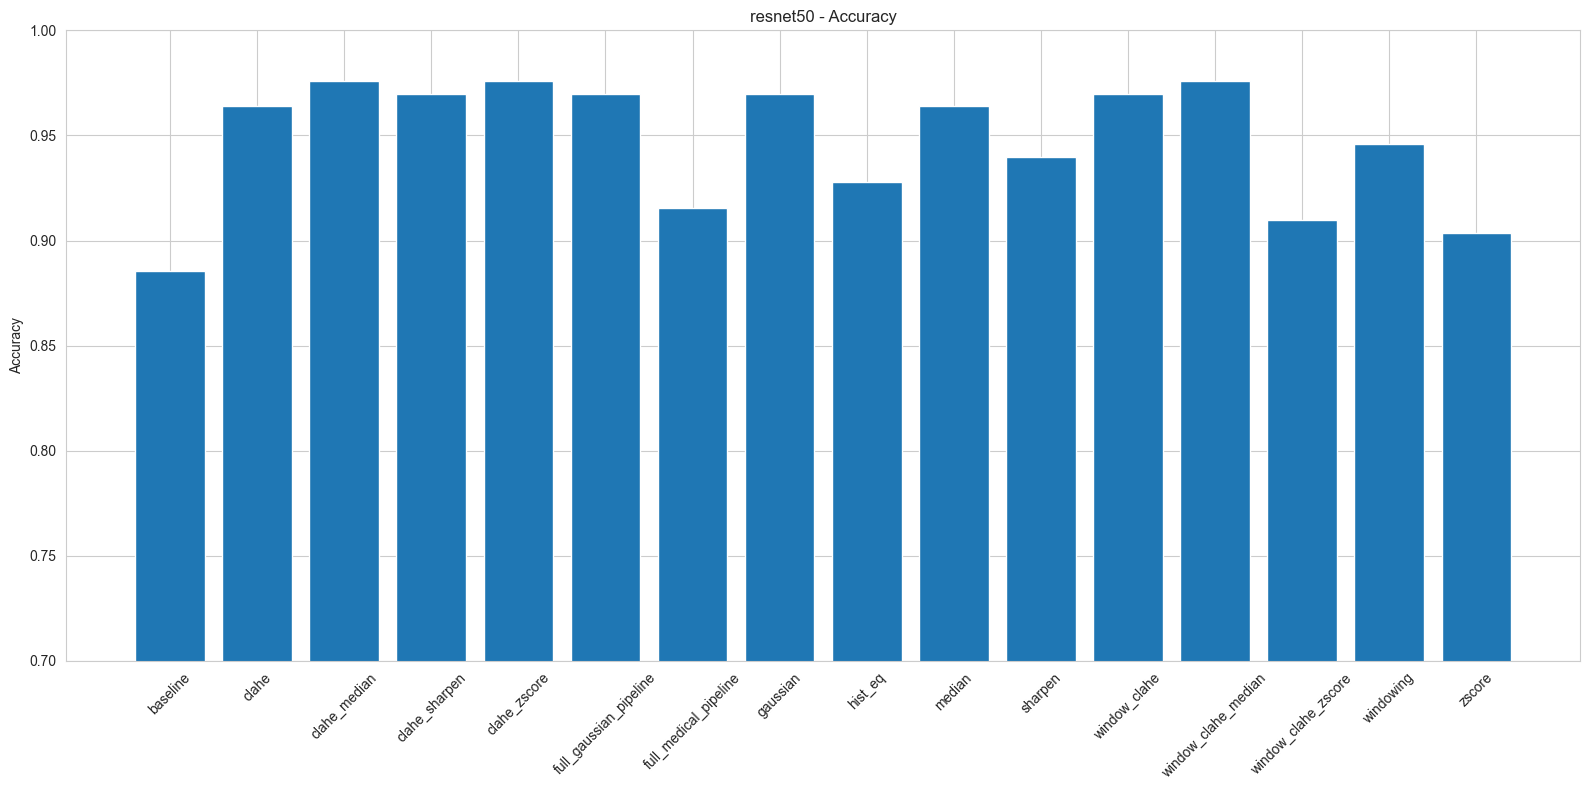

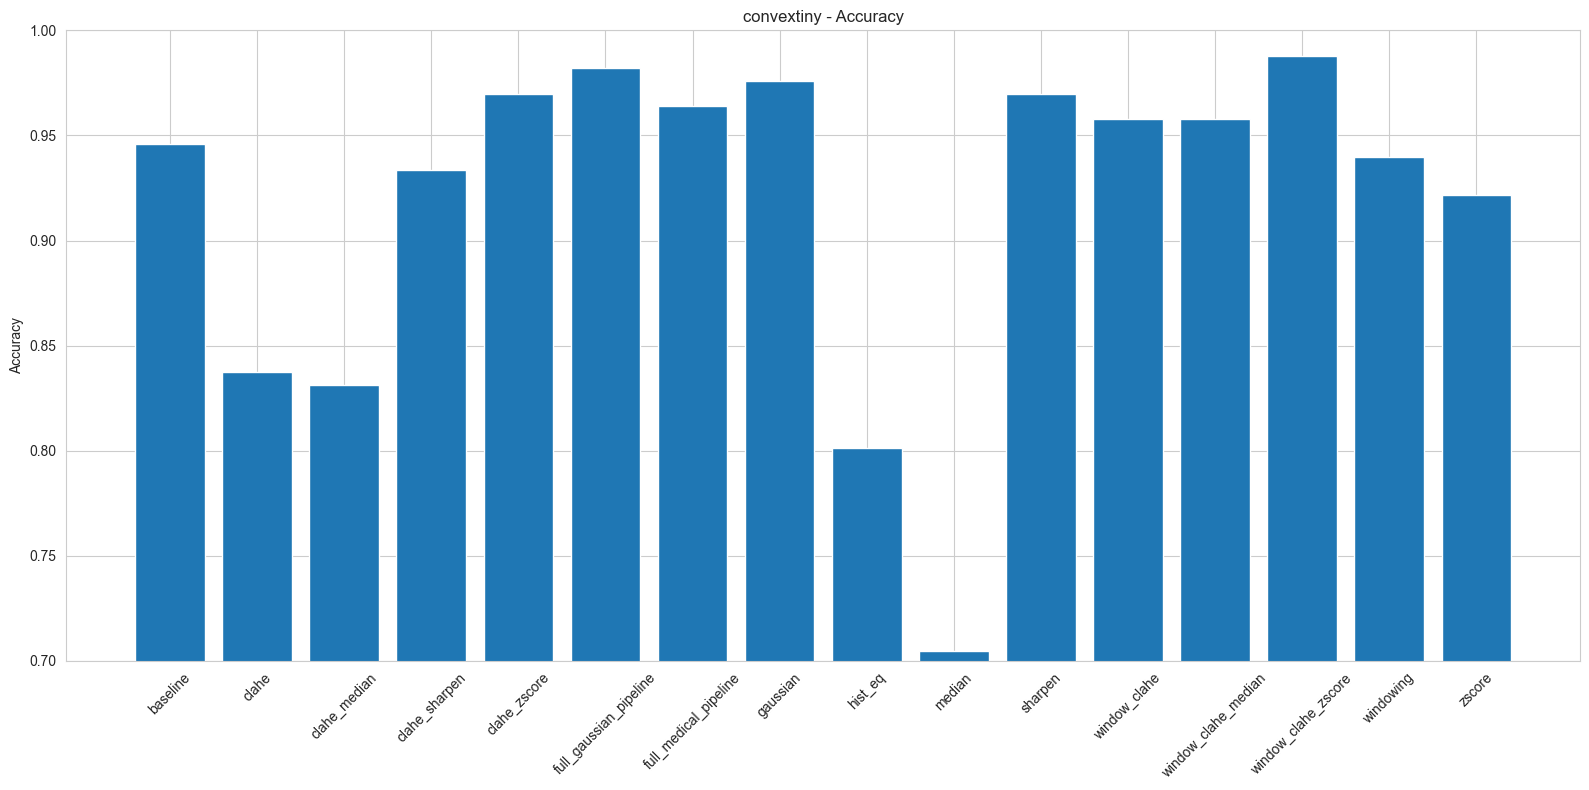

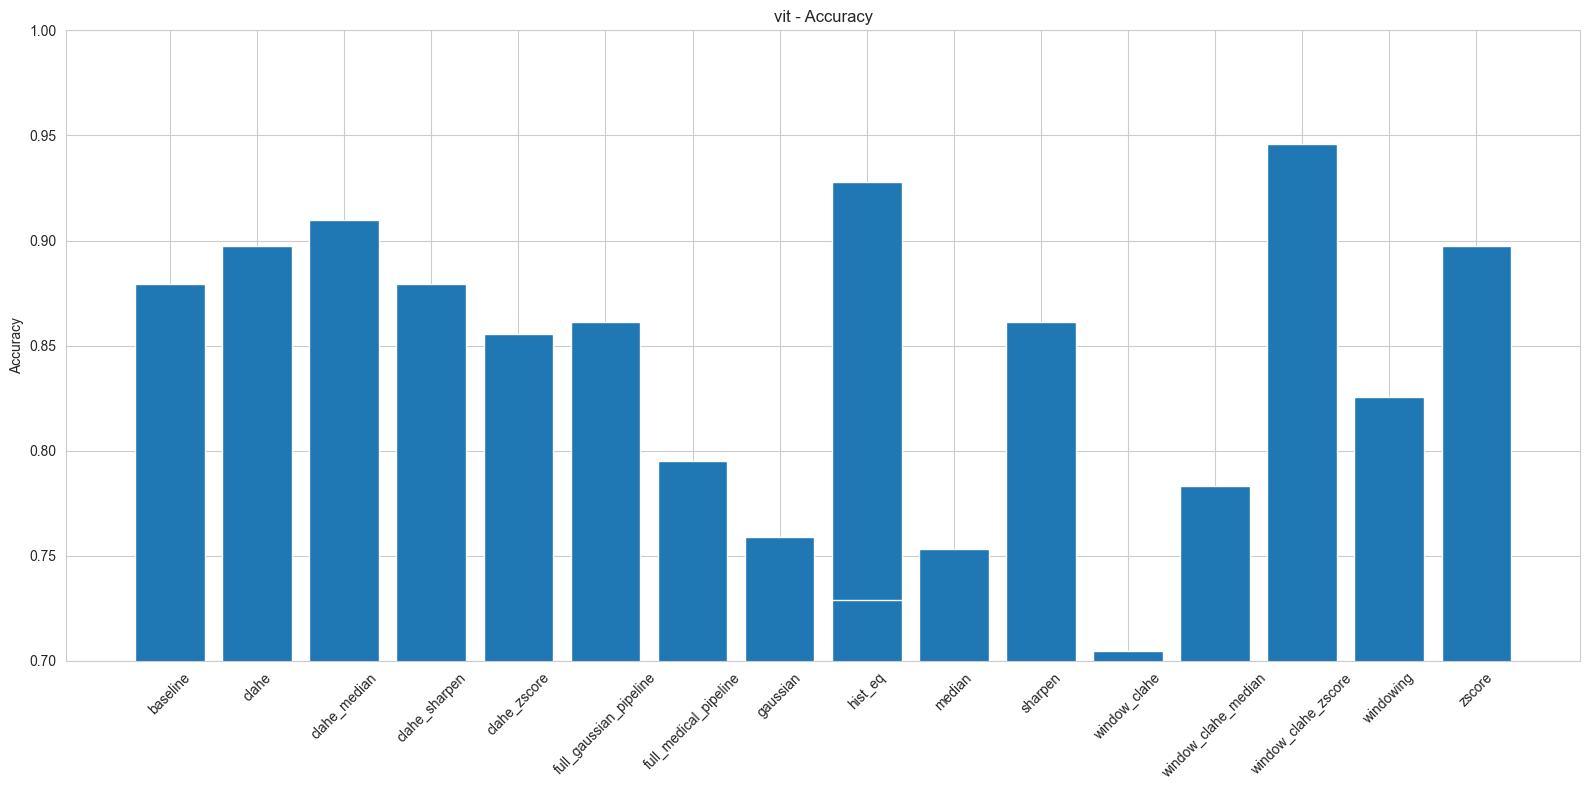

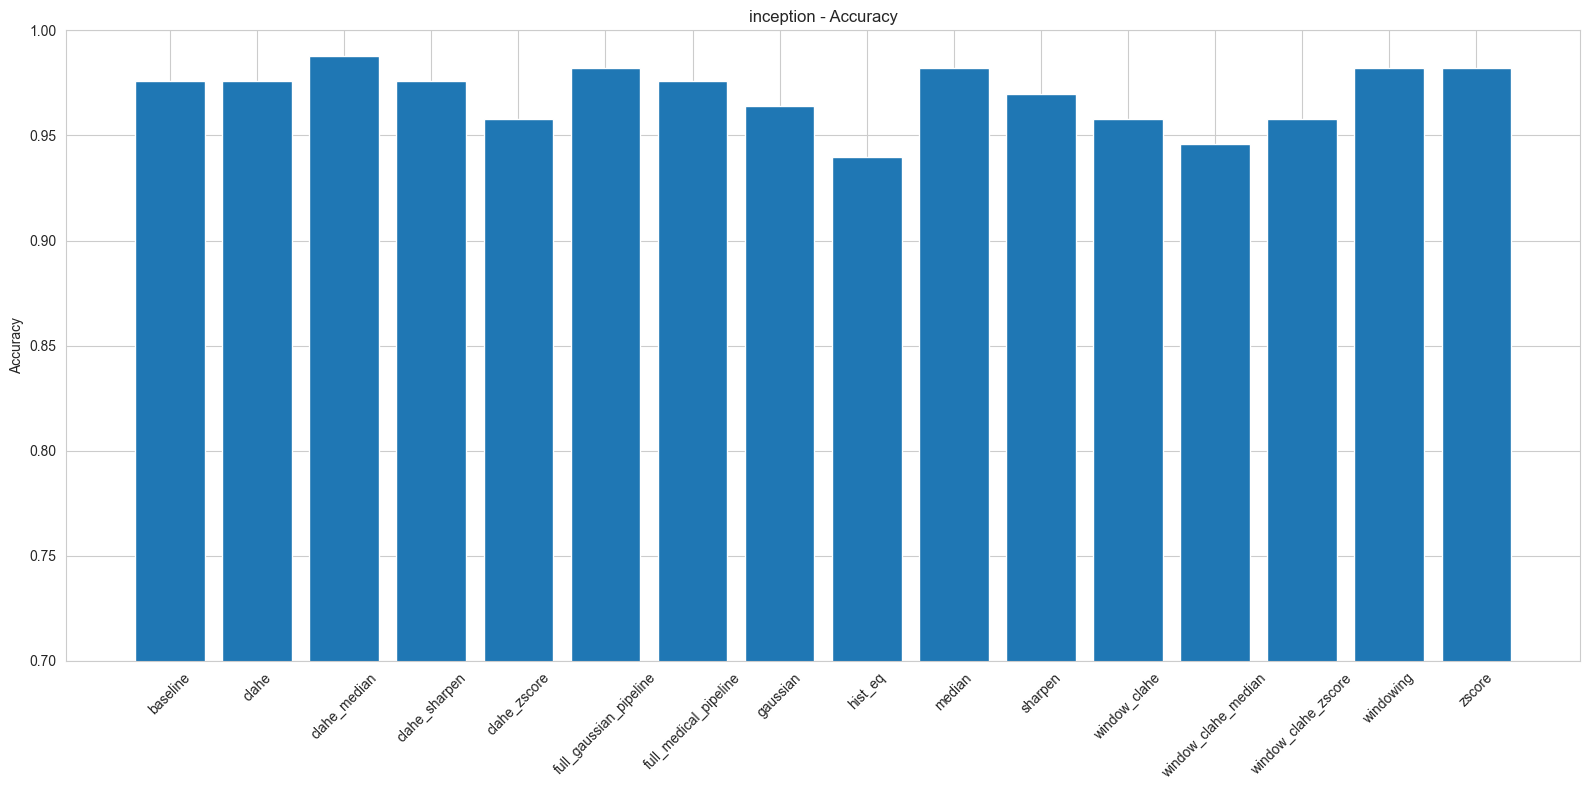

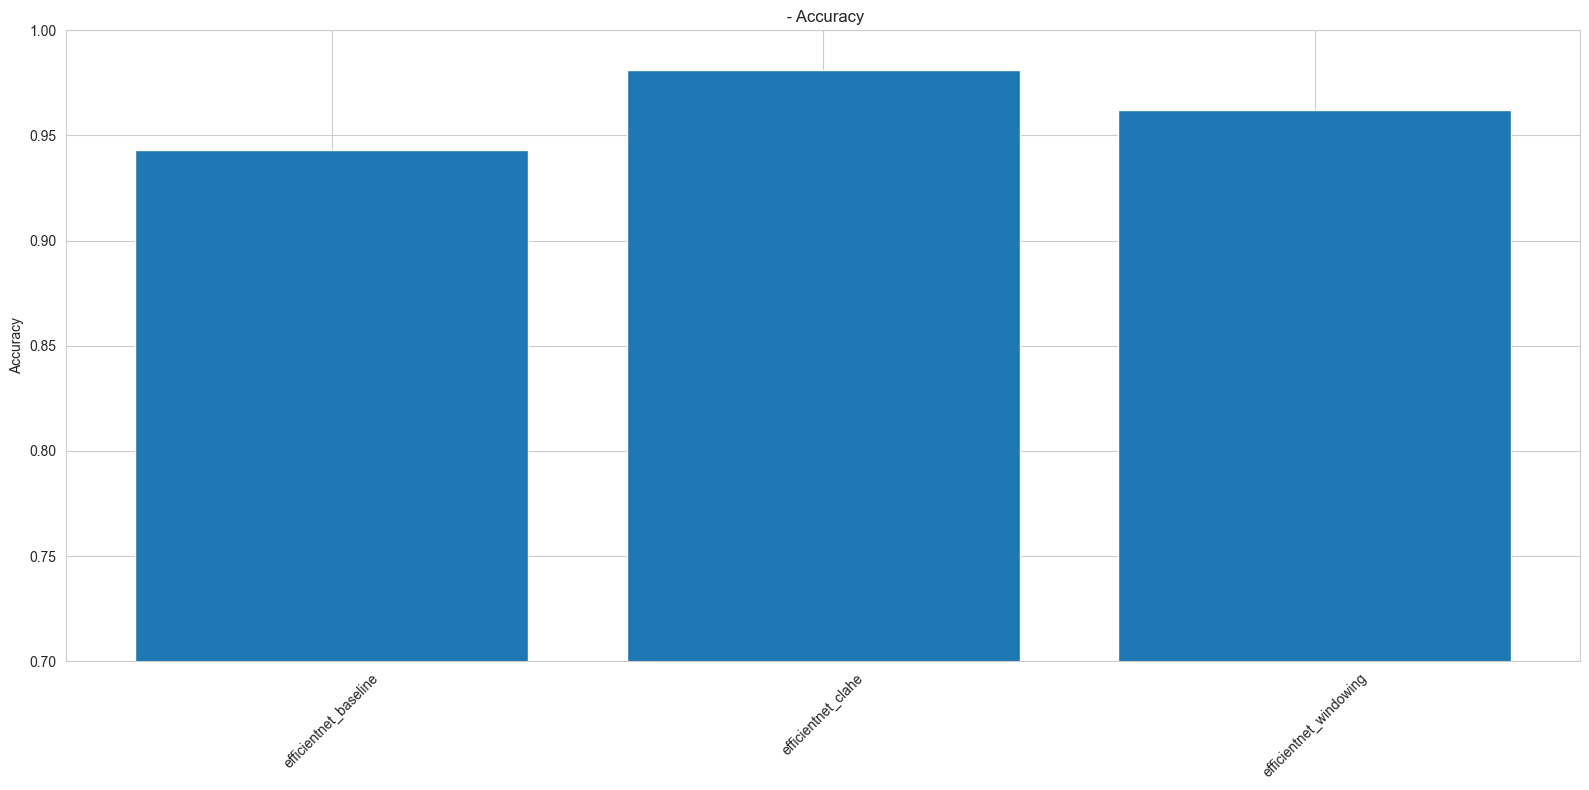

Charts generated successfully!


In [19]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/charts", exist_ok=True)

models = df["single_model"].unique()

for model in models:

    model_df = df[df["single_model"] == model]
    model_df = model_df.sort_values("config")

    configs = model_df["config"]

    # create single figure with 3 charts
    # fig, axes = plt.subplots(1, 1, figsize=(12, 10))

    plt.figure(figsize=(16,8))

    # -------- Test Accuracy --------
    plt.bar(configs, model_df["Accuracy"])
    plt.ylim(0.70,1)
    plt.title(f"{model} - Accuracy")
    plt.ylabel("Accuracy")
    # axes[0].set_ylim(0.7, 1)
    plt.tick_params(axis='x', rotation=45)

    # -------- Validation Accuracy --------
    # axes[1].bar(configs, model_df["Best_Val_Accuracy"])
    # axes[1].set_title(f"{model} - Best Validation Accuracy")
    # axes[1].set_ylabel("Val Accuracy")
    # axes[1].set_ylim(0.7, 1)
    # axes[1].tick_params(axis='x', rotation=45)

    # -------- Validation F1 --------
    # axes[2].bar(configs, model_df["Best_Val_f1"])
    # axes[2].set_title(f"{model} - Best Validation F1")
    # axes[2].set_ylabel("Val F1")
    # axes[2].set_ylim(0.7, 1)
    # axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()

    # plt.savefig(f"results/charts/{model}_performance.png")
    plt.show()
    plt.close()

print("Charts generated successfully!")

C:\Users\navne\AppData\Local\Temp\ipykernel_25028\3562518711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


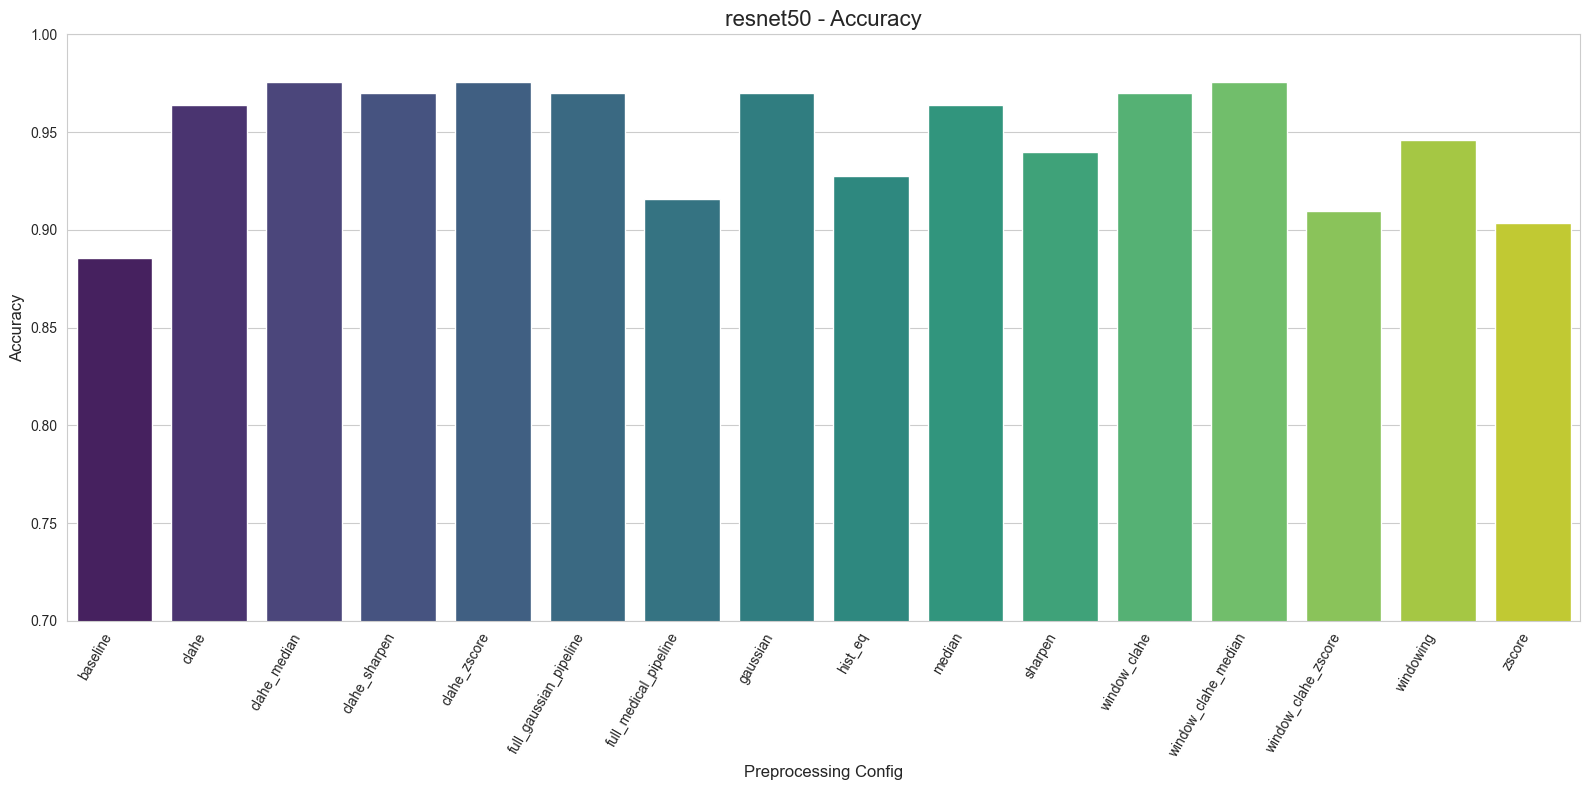

C:\Users\navne\AppData\Local\Temp\ipykernel_25028\3562518711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


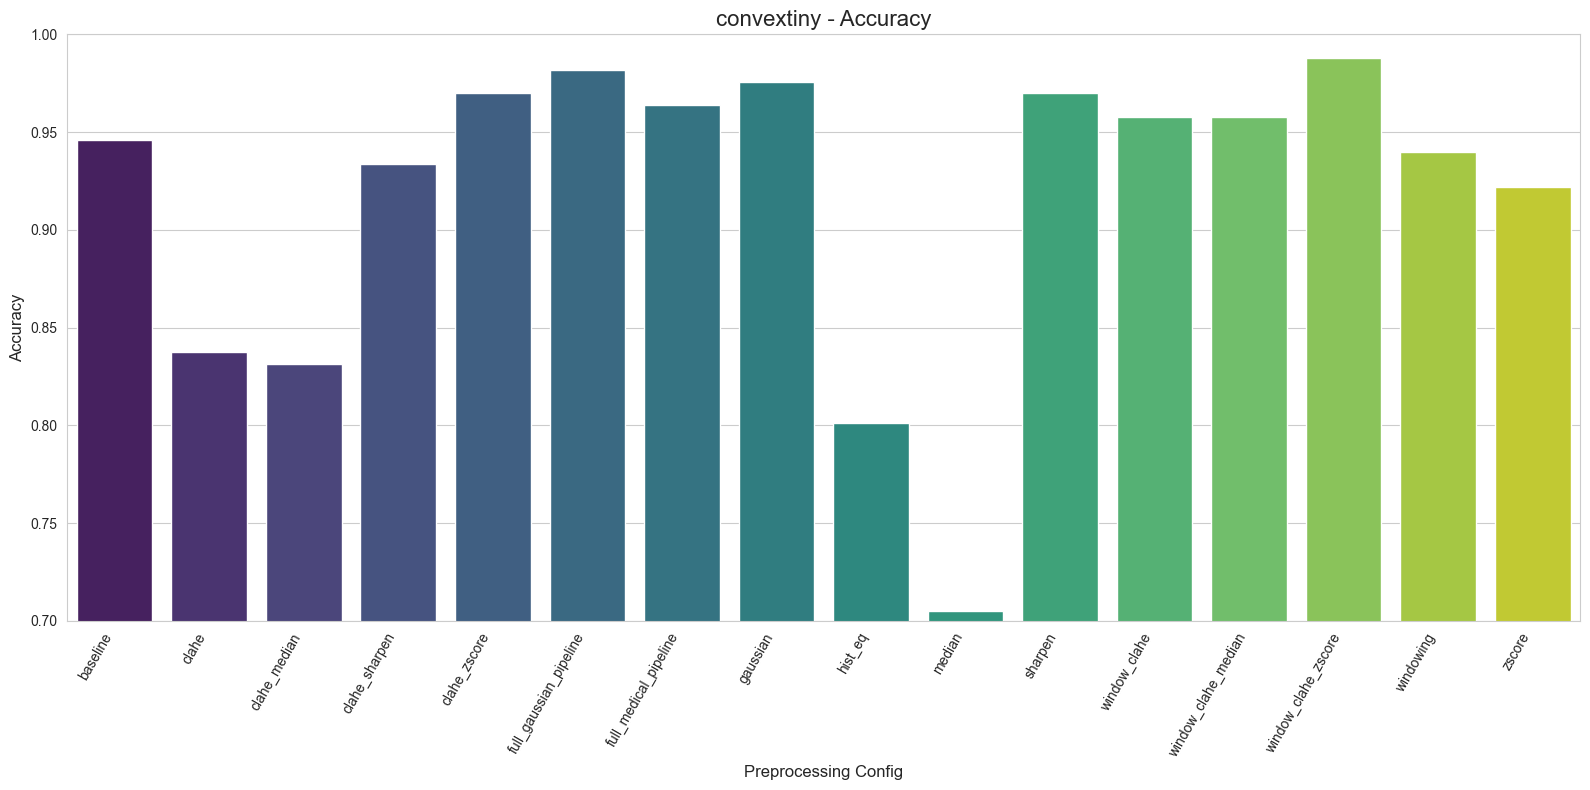

C:\Users\navne\AppData\Local\Temp\ipykernel_25028\3562518711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


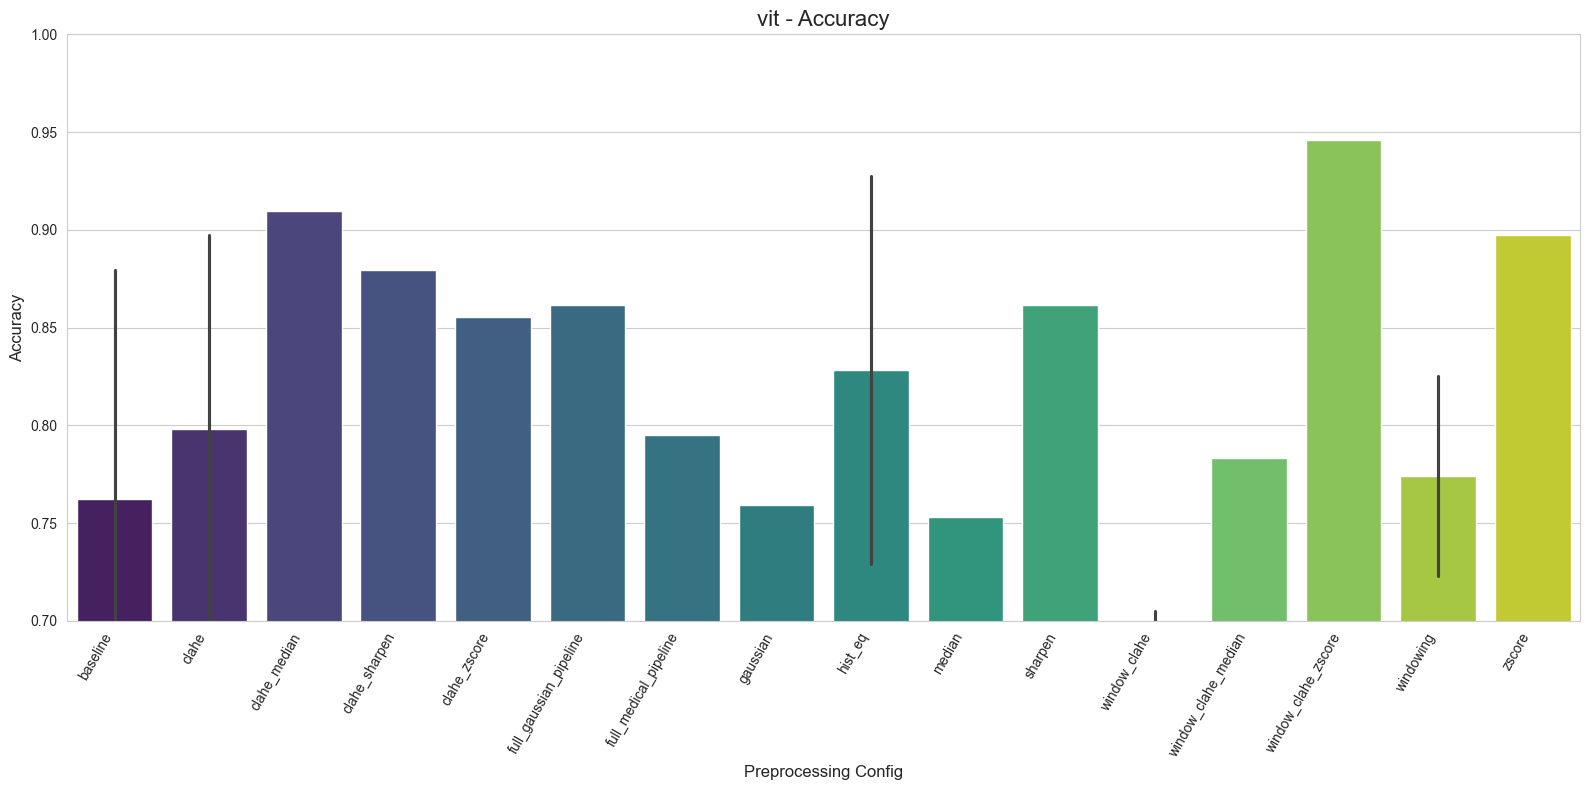

C:\Users\navne\AppData\Local\Temp\ipykernel_25028\3562518711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


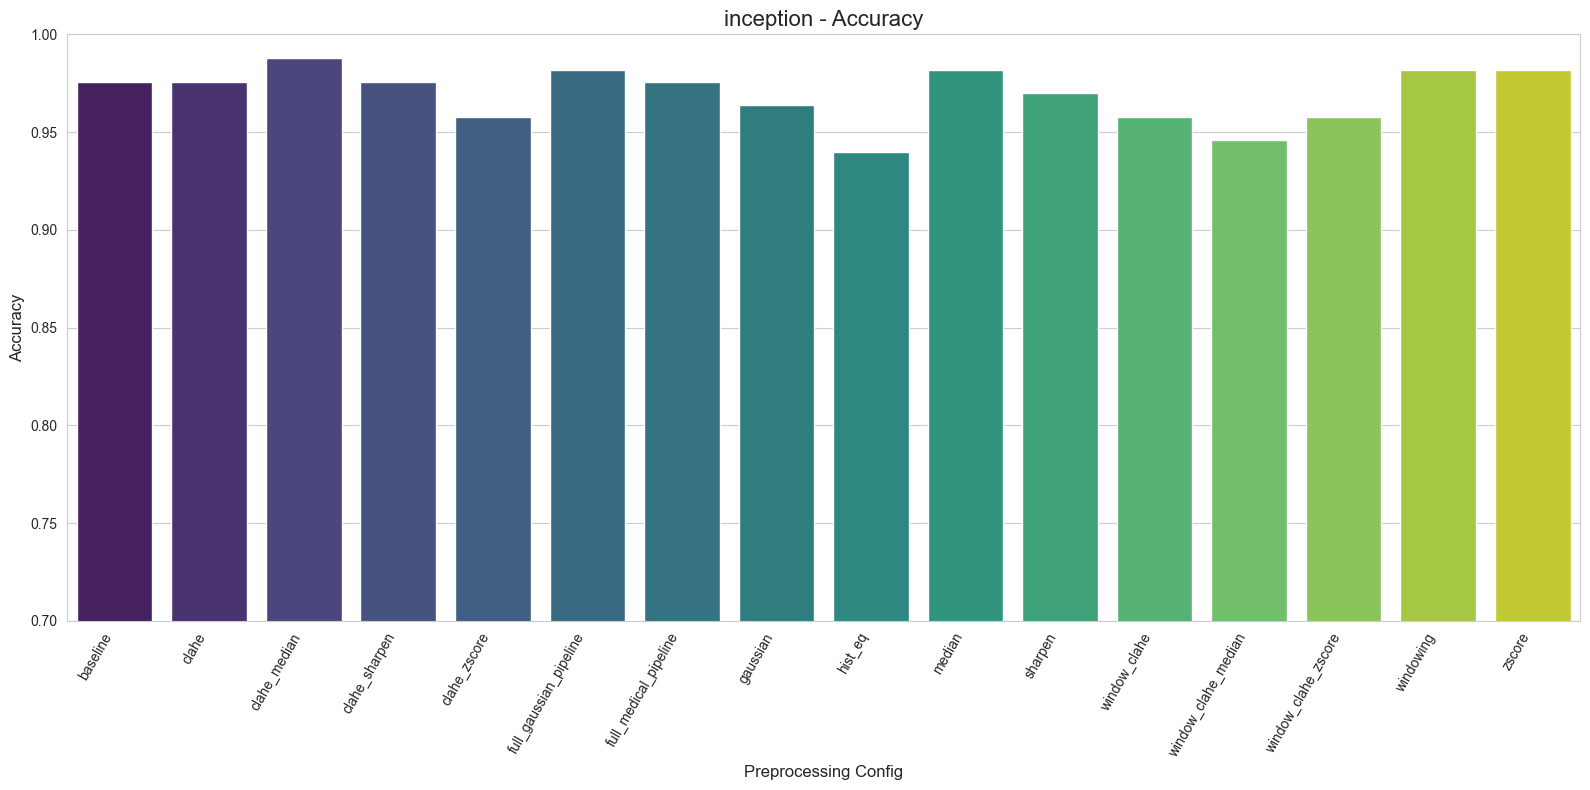

C:\Users\navne\AppData\Local\Temp\ipykernel_25028\3562518711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


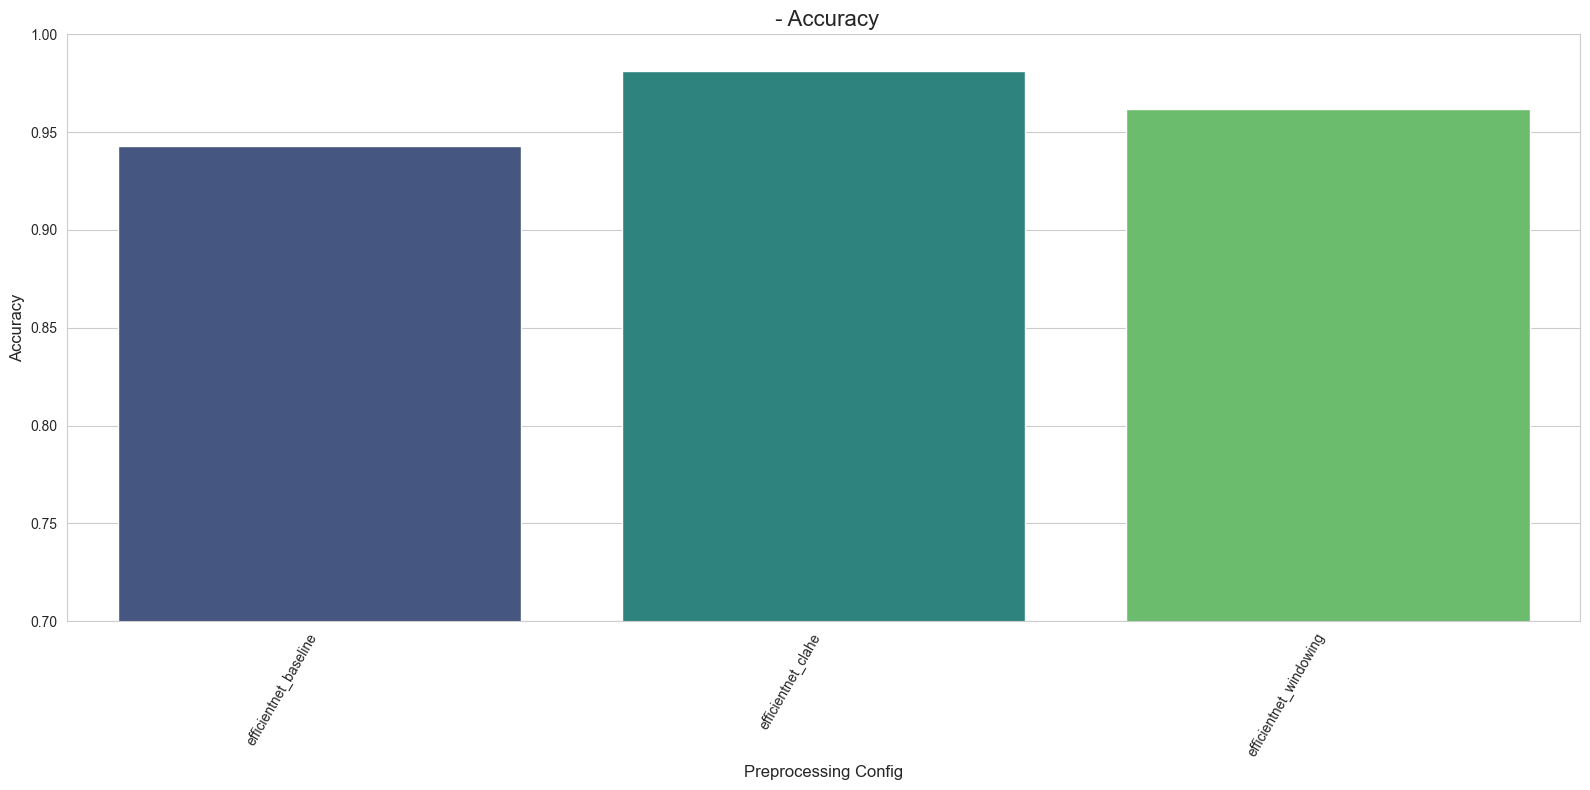

Charts generated successfully!


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("results/charts/charts-single_model", exist_ok=True)

sns.set_style("whitegrid")

models = df["single_model"].unique()

for model in models:

    model_df = df[df["single_model"] == model]
    model_df = model_df.sort_values("config")

    plt.figure(figsize=(16,8))

    sns.barplot(
        data=model_df,
        x="config",
        y="Accuracy",
        palette="viridis"
    )

    plt.ylim(0.70,1)

    plt.title(f"{model} - Accuracy", fontsize=16)
    plt.ylabel("Accuracy", fontsize=12)
    plt.xlabel("Preprocessing Config", fontsize=12)

    plt.xticks(rotation=60, ha="right")

    plt.tight_layout()

    # plt.savefig(f"results/charts/charts-single_model/{model}_accuracy.png")

    plt.show()
    plt.close()

print("Charts generated successfully!")

                                  Model  Accuracy  Precision    Recall  \
71              efficientnet_clahe_ep30  0.981043   0.981043  0.981043   
29  convextiny_window_clahe_zscore_ep20  0.987952   0.988323  0.987952   
60          inception_clahe_median_ep20  0.987952   0.989157  0.987952   
7            resnet50_clahe_median_ep20  0.975904   0.978288  0.975904   
50         vit_window_clahe_zscore_ep20  0.945783   0.948042  0.945783   

          F1  Epochs prep_windowing prep_clahe prep_hist_eq prep_gaussian  \
71  0.981043      30            NaN       True          NaN           NaN   
29  0.987692      20           True       True          NaN           NaN   
60  0.988172      20            NaN       True          NaN           NaN   
7   0.976387      20            NaN       True          NaN           NaN   
50  0.942956      20           True       True          NaN           NaN   

   prep_median prep_sharpen_flag prep_norm_type  Test_Accuracy single_model  \
71         Na

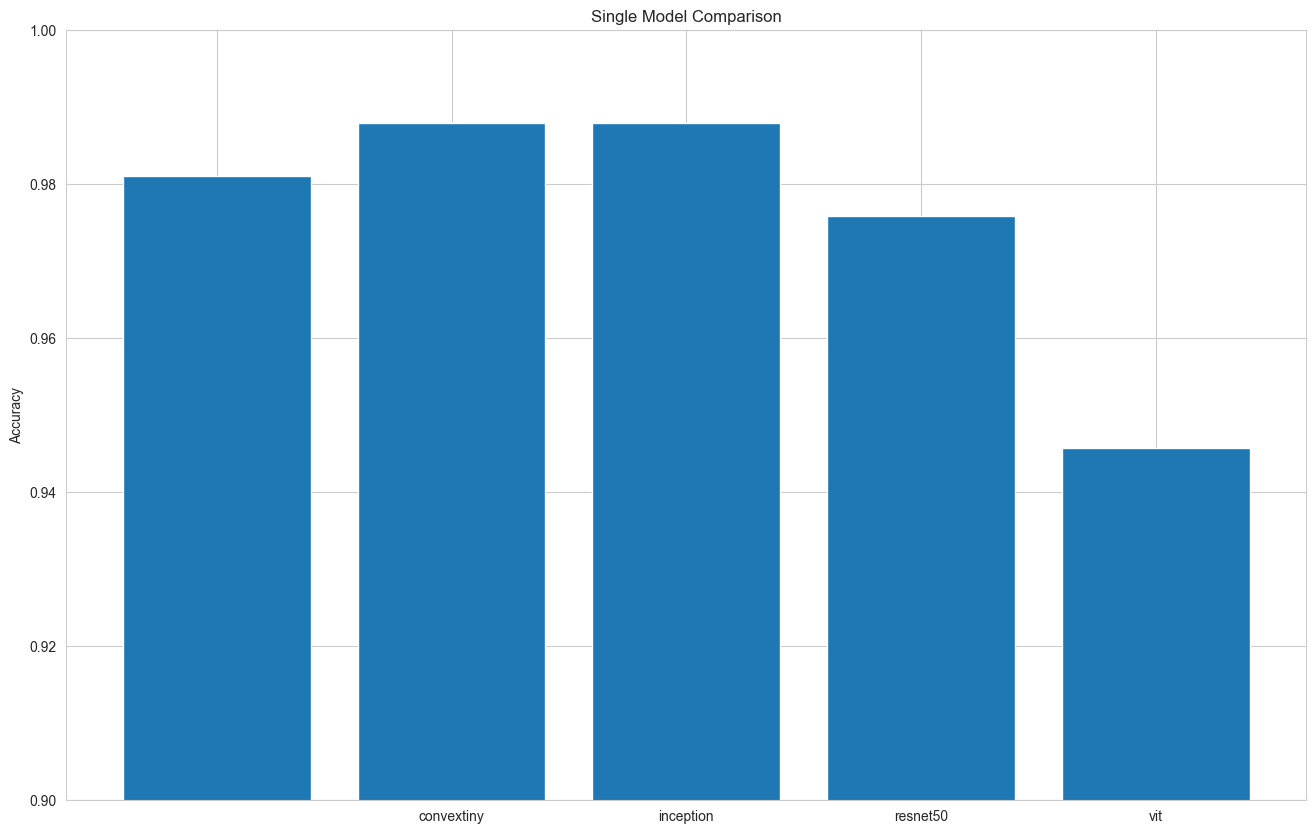

In [24]:
best_models = df.loc[df.groupby("single_model")["Accuracy"].idxmax()]
os.makedirs("results/charts/comparison",exist_ok=True)
print(best_models)

plt.figure(figsize=(16,10))
plt.bar(best_models["single_model"], best_models["Accuracy"])
plt.xticks(rotation=0)
plt.ylabel("Accuracy")
plt.ylim(0.90,1)
plt.savefig("results/charts/comparison/single_model_comparison.png")
plt.title("Single Model Comparison")
plt.show()